# 13. Experiment 1 — Corpus statistics

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\EGlaciers\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\EGlaciers\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


Đang đọc file: C:\Users\EGlaciers\Desktop\NLP-Apps\c4-train.00000-of-01024-30K.json.gz
Quá trình này có thể mất vài phút. Đang xử lý...
  -> Đã xử lý 5000 documents...
  -> Đã xử lý 10000 documents...
  -> Đã xử lý 15000 documents...
  -> Đã xử lý 20000 documents...
  -> Đã xử lý 25000 documents...
  -> Đã xử lý 30000 documents...

--- THỐNG KÊ CORPUS C4 (30K) ---
Số documents:   30,000
Số sentences:   604,051
Số tokens:      12,442,230
Vocabulary size: 261,046

-----------------------------------------------------------------
Model      | # unique n-grams     | # singletons (count=1)   
-----------------------------------------------------------------
Unigram    | 261,046              | 147,183                  
Bigram     | 2,834,223            | 1,990,834                
Trigram    | 7,050,055            | 6,000,842                
-----------------------------------------------------------------


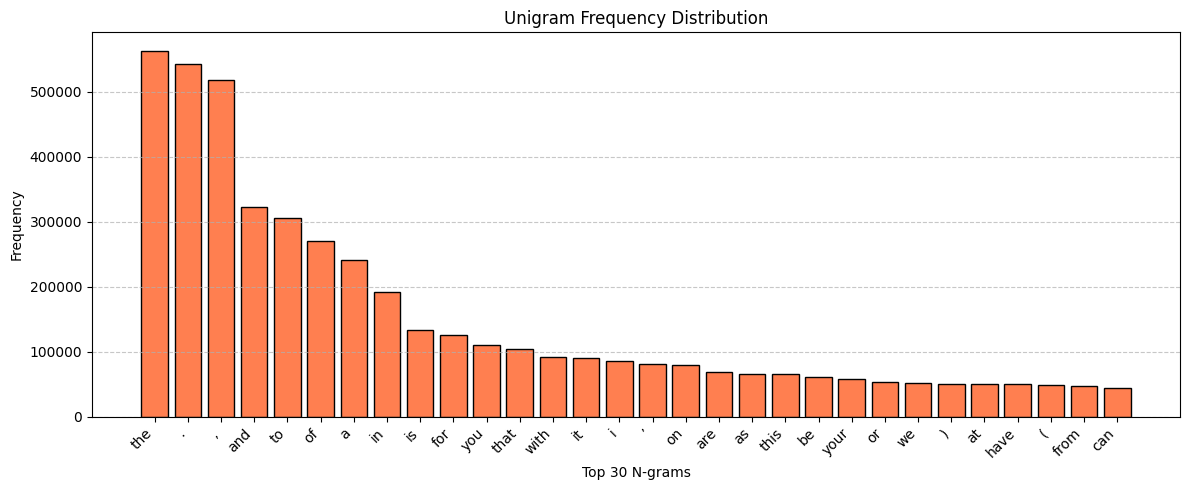

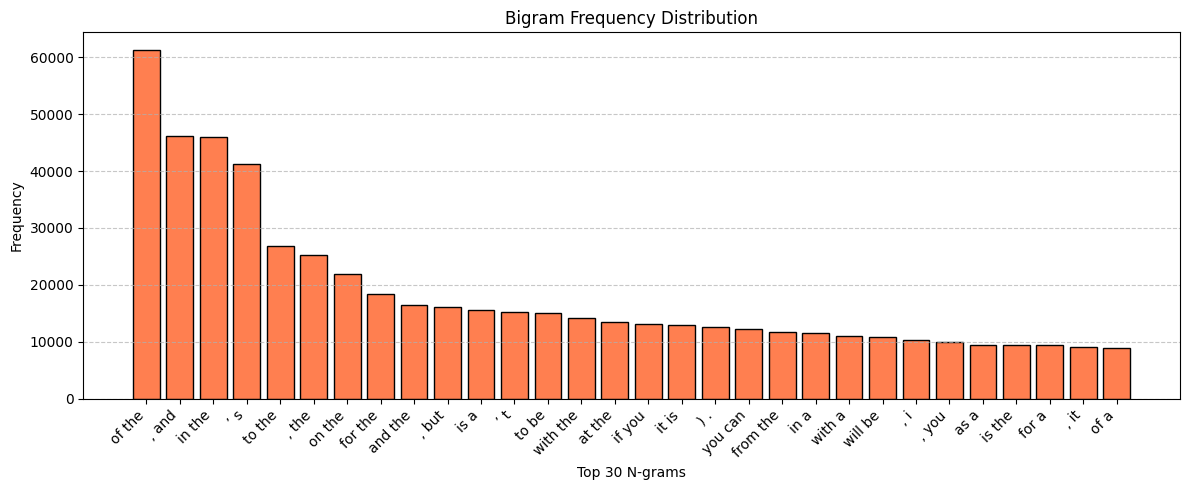

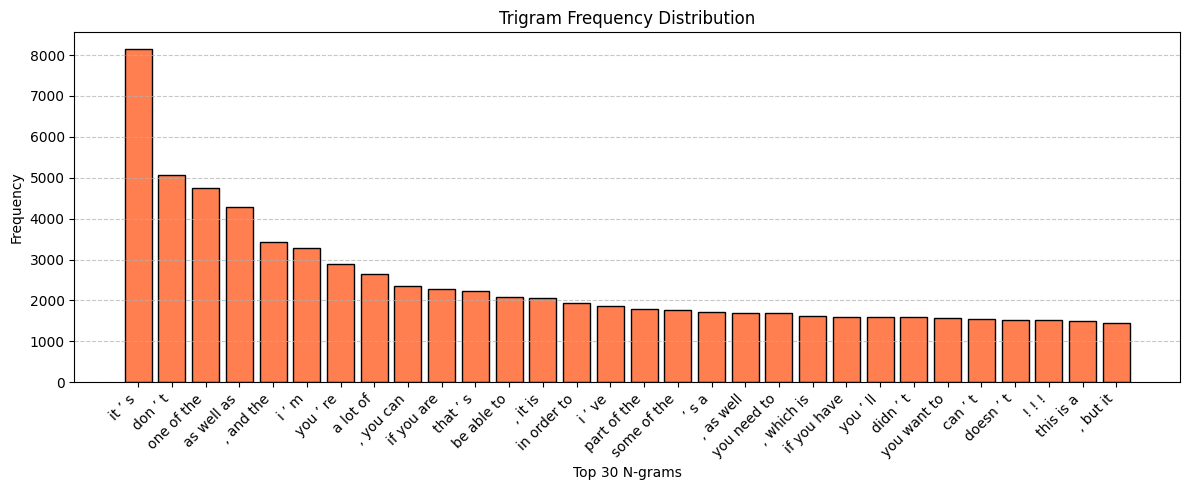

In [6]:
import gzip
import json
import nltk
from nltk.util import ngrams
from collections import Counter
import matplotlib.pyplot as plt

nltk.download('punkt')
nltk.download('punkt_tab')

def analyze_c4_corpus(file_path):
    num_docs = 0
    num_sentences = 0
    num_tokens = 0
    
    unigram_counts = Counter()
    bigram_counts = Counter()
    trigram_counts = Counter()
    
    print(f"Đang đọc file: {file_path}")
    print("Quá trình này có thể mất vài phút. Đang xử lý...")
    
    with gzip.open(file_path, 'rt', encoding='utf-8') as f:
        for line in f:
            try:
                doc = json.loads(line)
                text = doc.get("text", "").lower() 
                if not text:
                    continue
                    
                num_docs += 1
                
                sentences = nltk.sent_tokenize(text)
                num_sentences += len(sentences)
                
                for sent in sentences:
                    tokens = nltk.word_tokenize(sent)
                    num_tokens += len(tokens)
                    
                    unigram_counts.update(ngrams(tokens, 1))
                    bigram_counts.update(ngrams(tokens, 2))
                    trigram_counts.update(ngrams(tokens, 3))
                    
                if num_docs % 5000 == 0:
                    print(f"  -> Đã xử lý {num_docs} documents...")
                    
            except json.JSONDecodeError:
                continue

    vocab_size = len(unigram_counts)
    uni_singletons = sum(1 for v in unigram_counts.values() if v == 1)
    bi_singletons = sum(1 for v in bigram_counts.values() if v == 1)
    tri_singletons = sum(1 for v in trigram_counts.values() if v == 1)

    print("\n--- THỐNG KÊ CORPUS C4 (30K) ---")
    print(f"Số documents:   {num_docs:,}")
    print(f"Số sentences:   {num_sentences:,}")
    print(f"Số tokens:      {num_tokens:,}")
    print(f"Vocabulary size: {vocab_size:,}")
    print("\n" + "-" * 65)
    print(f"{'Model':<10} | {'# unique n-grams':<20} | {'# singletons (count=1)':<25}")
    print("-" * 65)
    print(f"{'Unigram':<10} | {len(unigram_counts):<20,} | {uni_singletons:<25,}")
    print(f"{'Bigram':<10} | {len(bigram_counts):<20,} | {bi_singletons:<25,}")
    print(f"{'Trigram':<10} | {len(trigram_counts):<20,} | {tri_singletons:<25,}")
    print("-" * 65)

    return unigram_counts, bigram_counts, trigram_counts

def plot_ngram_distribution(counts, title, top_k=30):
    most_common = counts.most_common(top_k)
    labels, values = zip(*most_common)
    
    labels = [' '.join(l) for l in labels]
    
    plt.figure(figsize=(12, 5))
    plt.bar(range(len(values)), values, color='coral', edgecolor='black')
    plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
    plt.title(title)
    plt.ylabel("Frequency")
    plt.xlabel(f"Top {top_k} N-grams")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

file_path = r"C:\Users\EGlaciers\Desktop\NLP-Apps\c4-train.00000-of-01024-30K.json.gz" 
unigram_cts, bigram_cts, trigram_cts = analyze_c4_corpus(file_path)

plot_ngram_distribution(unigram_cts, "Unigram Frequency Distribution")
plot_ngram_distribution(bigram_cts, "Bigram Frequency Distribution")
plot_ngram_distribution(trigram_cts, "Trigram Frequency Distribution")

# 14. Core implementation

In [20]:
%load_ext autoreload
%autoreload 2

from ngram_lm import NGramLanguageModel

# Tập corpus siêu nhỏ từ phần Calculation
toy_corpus = [
    "the cat eats fish",
    "the cat likes fish",
    "the dog eats meat"
]

bigram_model = NGramLanguageModel(n=2)
bigram_model.fit(toy_corpus)

print(f"P(cat|the) = {bigram_model.probability('the', 'cat'):.4f}") 

sent_prob = bigram_model.sentence_probability("the cat eats fish")
print(f"P(the cat eats fish) = {sent_prob:.4f}")

print("Sau chữ 'cat', xác suất các từ tiếp theo là:")
print(bigram_model.next_word_distribution('cat'))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Đang huấn luyện 2-gram model...
Huấn luyện xong! Vocabulary size: 9
P(cat|the) = 0.6667
P(the cat eats fish) = 0.1667
Sau chữ 'cat', xác suất các từ tiếp theo là:
{'eats': 0.5, 'likes': 0.5}


# 15. Log probability

In [21]:
# Xác suất thường
prob = bigram_model.sentence_probability("the cat eats fish")
print(f"Xác suất nguyên bản: {prob}")

# Xác suất log
log_p = bigram_model.sentence_log_probability("the cat eats fish")
print(f"Log probability: {log_p}")

Xác suất nguyên bản: 0.16666666666666666
Log probability: -1.791759469228055


# 16. Experiment 2 — MLE vs smoothing

In [22]:
import gzip
import json

def load_c4_splits(file_path, train_size=5000, valid_size=500, test_size=500):
    train_set, valid_set, test_set = [], [], []
    print("Đang load và chia dữ liệu...")
    
    with gzip.open(file_path, 'rt', encoding='utf-8') as f:
        for line in f:
            try:
                text = json.loads(line).get("text", "")
                if not text: continue
                
                if len(train_set) < train_size:
                    train_set.append(text)
                elif len(valid_set) < valid_size:
                    valid_set.append(text)
                elif len(test_set) < test_size:
                    test_set.append(text)
                else:
                    break 
            except json.JSONDecodeError:
                continue
                
    print(f"Hoàn tất! Train: {len(train_set)}, Valid: {len(valid_set)}, Test: {len(test_set)}")
    return train_set, valid_set, test_set

file_path = r"C:\Users\EGlaciers\Desktop\NLP-Apps\c4-train.00000-of-01024-30K.json.gz" 
train_set, valid_set, test_set = load_c4_splits(file_path, 5000, 500, 500)

print(f"{'Model':<16} | {'Train PPL':<12} | {'Valid PPL':<12} | {'Test PPL'}")
print("-" * 55)

for n, name in [(2, 'Bigram'), (3, 'Trigram')]:
    model = NGramLanguageModel(n=n)
    model.fit(train_set) 
    
    def format_ppl(ppl):
        return "inf" if ppl == float('inf') else f"{ppl:.2f}"

    # Đo MLE
    mle_train = format_ppl(model.corpus_perplexity(train_set, smoothing=False))
    mle_valid = format_ppl(model.corpus_perplexity(valid_set, smoothing=False))
    mle_test  = format_ppl(model.corpus_perplexity(test_set, smoothing=False))
    
    # Đo Laplace
    lap_train = format_ppl(model.corpus_perplexity(train_set, smoothing=True))
    lap_valid = format_ppl(model.corpus_perplexity(valid_set, smoothing=True))
    lap_test  = format_ppl(model.corpus_perplexity(test_set, smoothing=True))
    
    print(f"{name} MLE       | {mle_train:<12} | {mle_valid:<12} | {mle_test}")
    print(f"{name} Laplace   | {lap_train:<12} | {lap_valid:<12} | {lap_test}")
    print("-" * 55)

Đang load và chia dữ liệu...
Hoàn tất! Train: 5000, Valid: 500, Test: 500
Model            | Train PPL    | Valid PPL    | Test PPL
-------------------------------------------------------
Đang huấn luyện 2-gram model...
Huấn luyện xong! Vocabulary size: 81328
Bigram MLE       | 85.94        | inf          | inf
Bigram Laplace   | 3761.10      | 5283.85      | 5394.72
-------------------------------------------------------
Đang huấn luyện 3-gram model...
Huấn luyện xong! Vocabulary size: 81328
Trigram MLE       | 7.79         | inf          | inf
Trigram Laplace   | 19061.43     | 33224.02     | 34108.31
-------------------------------------------------------


# 19. Experiment 3 — Perplexity

In [23]:
print("Bắt đầu chạy Experiment 3 (Có sử dụng Laplace Smoothing)...")
print(f"{'Model':<12} | {'Train PPL':<15} | {'Validation PPL':<15} | {'Test PPL'}")
print("-" * 65)

for n, name in [(1, 'Unigram'), (2, 'Bigram'), (3, 'Trigram')]:
    model = NGramLanguageModel(n=n)
    model.fit(train_set)
    
    train_ppl = model.corpus_perplexity(train_set, smoothing=True)
    valid_ppl = model.corpus_perplexity(valid_set, smoothing=True)
    test_ppl = model.corpus_perplexity(test_set, smoothing=True)
    
    print(f"{name:<12} | {train_ppl:<15.2f} | {valid_ppl:<15.2f} | {test_ppl:.2f}")
    print("-" * 65)

Bắt đầu chạy Experiment 3 (Có sử dụng Laplace Smoothing)...
Model        | Train PPL       | Validation PPL  | Test PPL
-----------------------------------------------------------------
Đang huấn luyện 1-gram model...
Huấn luyện xong! Vocabulary size: 81328
Unigram      | 1261.72         | 1394.55         | 1408.03
-----------------------------------------------------------------
Đang huấn luyện 2-gram model...
Huấn luyện xong! Vocabulary size: 81328
Bigram       | 3761.10         | 5283.85         | 5394.72
-----------------------------------------------------------------
Đang huấn luyện 3-gram model...
Huấn luyện xong! Vocabulary size: 81328
Trigram      | 19061.43        | 33224.02        | 34108.31
-----------------------------------------------------------------


# 20. Application — Next-word prediction

In [24]:
def show_predictions(model, context_str, top_k=4):
    dist = model.next_word_distribution(context_str)
    
    print(f"Input:\n{context_str}")
    print("Output:")
    
    top_items = list(dist.items())[:top_k]
    if not top_items:
        print("  (Không có dữ liệu dự đoán cho context này)")
    else:
        for i, (word, prob) in enumerate(top_items, 1):
            print(f"{i}. {word:<10} {prob:.4f}")
    print("-" * 30)

# Khởi tạo mô hình Trigram (nếu chưa có)
# trigram_model = NGramLanguageModel(n=3)
# trigram_model.fit(train_set)

contexts = [
    "the cat",
    "natural language",
    "machine learning",
    "in order",
    "one of"
]

print("--- NEXT-WORD PREDICTION ---")
for ctx in contexts:
    show_predictions(model, ctx) 

--- NEXT-WORD PREDICTION ---
Input:
the cat
Output:
1. that       0.1250
2. lovers     0.1250
3. with       0.1250
4. had        0.1250
------------------------------
Input:
natural language
Output:
  (Không có dữ liệu dự đoán cho context này)
------------------------------
Input:
machine learning
Output:
1. and        0.2174
2. approaches 0.1739
3. models     0.0870
4. portfolio  0.0435
------------------------------
Input:
in order
Output:
1. to         0.8837
2. for        0.0499
3. that       0.0166
4. over       0.0028
------------------------------
Input:
one of
Output:
1. the        0.5643
2. our        0.0669
3. my         0.0669
4. those      0.0404
------------------------------


# 21. Application — Sentence ranking

In [ ]:
import math
import nltk

def rank_continuations(model, context, candidates):
    print(f"Context: '{context}'")
    print("-" * 50)
    
    results = []
    ctx_tokens = nltk.word_tokenize(context.lower())
    
    for cand in candidates:
        cand_tokens = nltk.word_tokenize(cand.lower())
        
        combined = ctx_tokens + cand_tokens + ['</s>']
        
        if model.n > 1:
            padded = ['<s>'] * (model.n - 1) + combined
        else:
            padded = combined
            
        log_prob = 0.0
        
        start_idx = (model.n - 1) + len(ctx_tokens)
        
        for i in range(start_idx, len(padded)):
            word = padded[i]
            ctx = tuple(padded[i - model.n + 1 : i])
            
            p = model.laplace_probability(ctx, word)
            log_prob += math.log(p)
            
        results.append((cand, log_prob))
        
    results.sort(key=lambda x: x[1], reverse=True)
    
    print(f"{'Rank':<5} | {'Candidate':<30} | {'Log Prob (Score)'}")
    print("-" * 50)
    for i, (cand, score) in enumerate(results, 1):
        print(f"#{i:<4} | {cand:<30} | {score:.4f}")
    print("\n")

context = "machine learning"
candidates = [
    "is useful for natural language processing", 
    "studies language models",
    "banana computer quickly"
]

rank_continuations(model, context, candidates)

Context: 'machine learning'
--------------------------------------------------
Rank  | Candidate                      | Log Prob (Score)
--------------------------------------------------
#1    | studies language models        | -45.2253
#2    | banana computer quickly        | -45.2253
#3    | is useful for natural language processing | -76.9475


